# 02 · Validating the automated pipeline

Notebook 01 found two planets by hand. This notebook checks that the **automated pipeline** in `src/pipeline.py` gets the same answers with a single function call, and without any hand-picked settings.

These are **regression tests**: before trusting a pipeline on unknown stars, it must reproduce results we already know. If a later code change breaks something, rerunning this notebook will catch it.

## What `process_star` does

One call runs the whole method from notebook 01, automatically:

1. **Fetch** the star's TESS light curves, choosing the sectors closest together in time
2. **Clean**: trim the first day after every data gap (where instrument glitches live), drop short leftover segments, and remove only *upward* spikes, so transits are never clipped
3. **Flatten → Find → Fence → Flatten**: the two-pass detrending from notebook 01, with a BLS search sized to the data's time span and a coarse-to-fine period refinement
4. **Measure** depth, noise, signal-to-noise, reliability flags, and the vetting features used by the classifier

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message=".*oktopus.*")

import sys
sys.path.append("..")
import pandas as pd
from src.pipeline import process_star, plot_summary

## Test 1: WASP-18 b (one sector)

The expected answer, from notebook 01 and the published value: a period of about **0.9415 days** and a depth of about **1.09%** (~10,900 ppm).

In [2]:
summary, data = process_star("WASP-18", max_sectors=1, return_data=True)

### Reading the diagnostic plot

Every star gets the same three-panel summary:

- **Top: the light curve.** Grey is the raw data, blue is what remains after cleaning. Where grey shows without blue, the cleaning removed it.
- **Middle: the BLS periodogram** (first pass). The red dashed line marks the detected period. A trustworthy detection is one tall peak plus its family of aliases.
- **Bottom: the folded transit** after the second, masked flatten, with the final period, depth, and SNR in the title. A planet should look like a symmetric U.

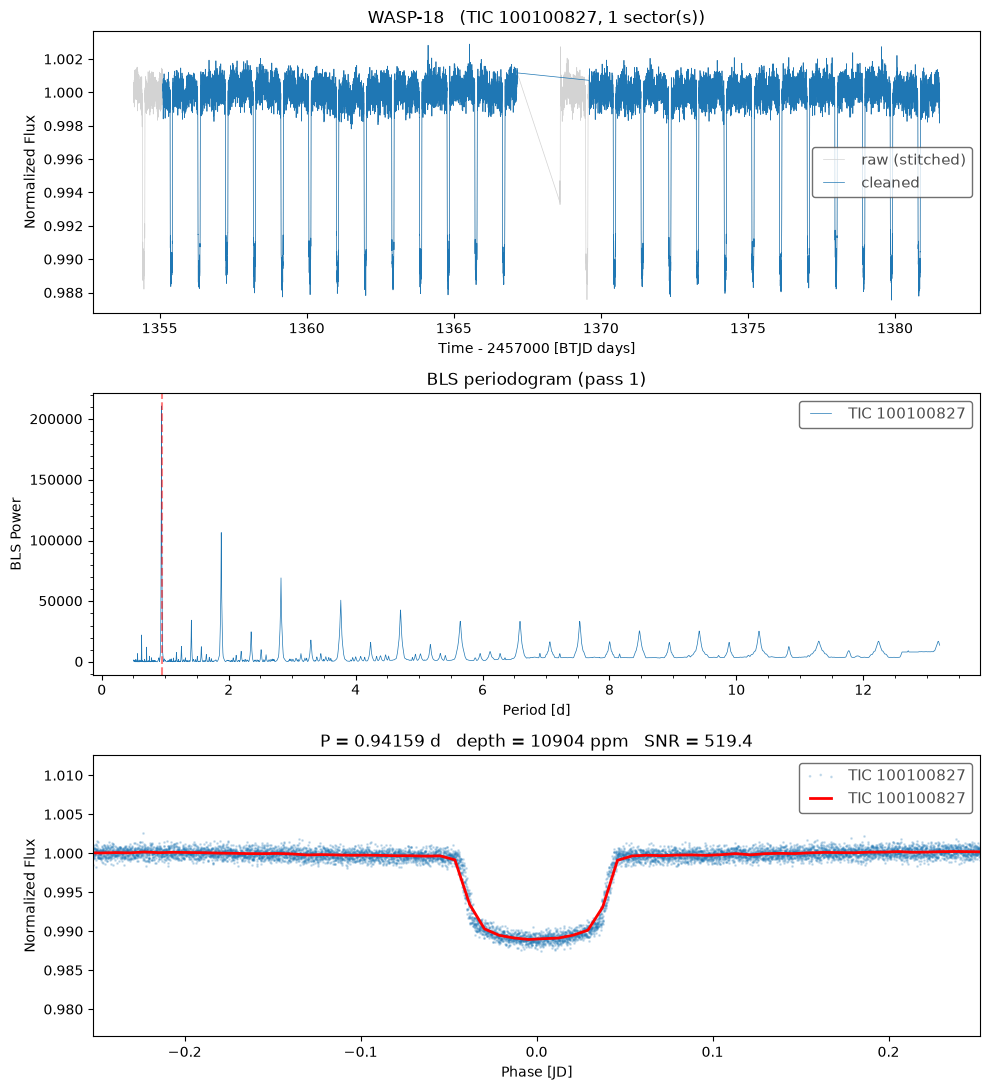

In [3]:
plot_summary(summary, data)

## Test 2: Pi Mensae c (up to three sectors)

The hard case: a ~300 ppm transit. Here the pipeline has to remove the instrument glitches **on its own**, which notebook 01 did by hand. Expected: a period of about **6.27 days** and a depth of about **300 ppm**.

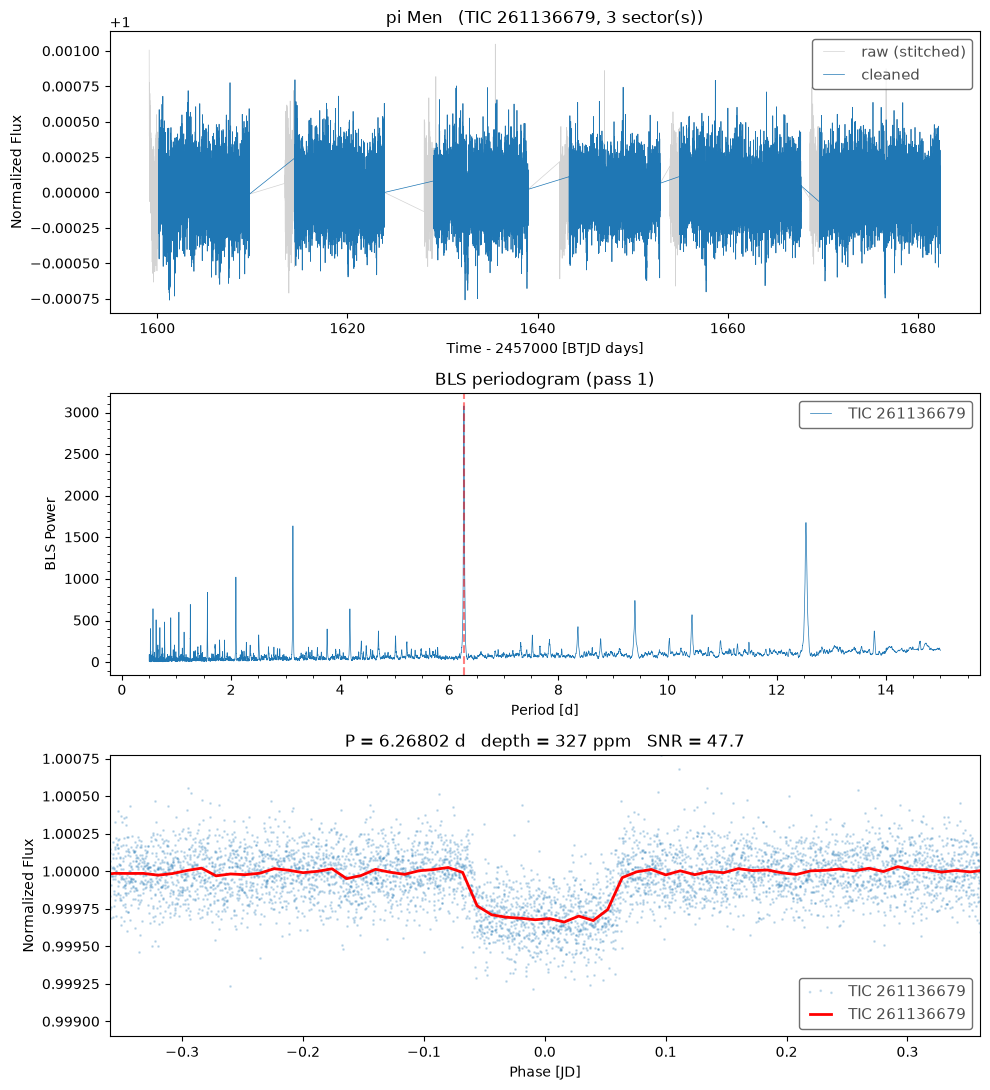

In [4]:
summary_pi, data_pi = process_star("pi Men", max_sectors=3, return_data=True)
plot_summary(summary_pi, data_pi)

## Results side by side

The key numbers for both stars, plus the reliability flags every detection now carries:

- **`snr`**: signal-to-noise ratio. A detection needs at least 7 to count.
- **`n_transits`**: how many individual transits had data. Fewer than 3 is unreliable.
- **`at_search_edge`**: whether the period sits at the edge of the search range, a warning sign.

In [5]:
cols = ["target", "sectors", "period_days", "duration_days", "depth_ppm",
        "snr", "snr_red", "n_transits", "at_search_edge"]
pd.DataFrame([summary, summary_pi])[cols]

,target,sectors,period_days,duration_days,depth_ppm,snr,snr_red,n_transits,at_search_edge
0,WASP-18,2,0.94159,0.084,10903.788582,519.383340,327.831736,25,False
1,pi Men,11 12 13,6.26802,0.120,327.101384,47.724864,38.049485,11,False


## Automatic checks

Looking at numbers by eye is easy to skip. These checks turn the expected answers into rules, so the notebook reports a clear pass or fail. The tolerances allow for normal small differences (for example, different sectors give slightly different depths) while still catching anything genuinely broken.

In [6]:
def check(name, value, expected, tolerance):
    ok = abs(value - expected) <= tolerance
    print(f"{'Pass' if ok else 'Fail'}  {name}: {value:.5f}  (expected {expected} ± {tolerance})")
    return ok

results = [check("WASP-18 b period (d)", summary["period_days"], 0.94145, 0.001),
    check("WASP-18 b depth (ppm)", summary["depth_ppm"], 10900, 800),
    check("Pi Mensae c period (d)", summary_pi["period_days"], 6.2678,  0.005),
    check("Pi Mensae c depth (ppm)", summary_pi["depth_ppm"], 310, 60),]

snr_ok = summary_pi["snr"] >= 7
print(f"{'Pass' if snr_ok else 'Fail'}  Pi Mensae c SNR: {summary_pi['snr']:.1f}  (must be at least 7)")
results.append(snr_ok)
print()
print("All Tests Passed" if all(results) else "Some Tests Failed: investigate before trusting new results")

Pass  WASP-18 b period (d): 0.94159  (expected 0.94145 ± 0.001)
Pass  WASP-18 b depth (ppm): 10903.78858  (expected 10900 ± 800)
Pass  Pi Mensae c period (d): 6.26802  (expected 6.2678 ± 0.005)
Pass  Pi Mensae c depth (ppm): 327.10138  (expected 310 ± 60)
Pass  Pi Mensae c SNR: 47.7  (must be at least 7)

All Tests Passed


## Summary

The pipeline reproduces both known planets automatically, including Pi Mensae c, where it had to find and remove the instrument glitches by itself. That makes it ready to run on stars where the answer *isn't* known: the 100-star benchmark in notebook 03.

**Rerun this notebook after any change to `src/pipeline.py`.** If a check fails, the change broke something.